---
## This script will create "Figure 2" for the paper draft of June '26
#### Implementing region-stratified resampling/bootstrap, and homogeneity test
##### Noel Siegert, 6/23/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
script = 'Fig2_resubmissionFeb26-homogtest.ipynb'

In [5]:
# dataframe with the stations we are using (including homogeneity assessment)
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded_withHomogTest.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [6]:
# open hw data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!

# thw
thw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.heatwaves.nc')

In [7]:
def bin_lat_scatters_densitywtd_bootCI_forFig2d(latbins, lats, lons, dat, nboot, radius_deg):
    '''
    Like "bin_lat_scatters_densitywtd_bootCI()" but this one takes in a 2-d "dat" array

    # like the one prior, but I'm just not hard-coding the shape of the output arrays...

    maybe I should just consolidate this with the other one so I'm not hardcoding???

    6/23/26
    '''

    # random seed
    rng = np.random.default_rng(27)
    
    # empty arrays to hold output
    binned_boots = np.zeros(shape=(len(latbins)-1, nboot, dat.shape[1])) * np.nan # dims = [lat_bin, bootstrap_mean_draw, level]
    bin_midpoints = np.zeros(len(latbins)-1)
    bin_n_obs = np.zeros(len(latbins)-1)
    
    i = 0
    
    # for each lat bin
    while i < len(latbins)-1:

#        print(i)
        
        # sel lat bin bounds, generate bin mask
        bot_bin = latbins[i]
        top_bin = latbins[i+1]
        binmask = (lats >= bot_bin) * (lats < top_bin)
    
    #        print(i, bot_bin, top_bin)
    
        # skip bin if there are no obs in that bin
        if np.sum(binmask) == 0:
#            print('skip this bin.')
            bin_midpoints[i] = ((bot_bin+top_bin)/2)
            bin_n_obs[i] = 0
            i += 1
            continue
    
        # set vals to send to bootstrap
        dat_bin = dat[binmask] # this still makes 2-d, nice
        lats_bin = lats[binmask]
        lons_bin = lons[binmask]
        
        # distance-weights for this lat bin
        weights = compute_density_weights(lats=lats_bin, lons=lons_bin, radius_deg=radius_deg)
        
        # empty array to store bootstrap draws
        boot_stats = np.zeros(shape=(nboot, dat_bin.shape[1])) * np.nan # shape is now [nboot, timestep (month)]
        
        # do the bootstrapped mean
        for b in range(nboot):
            idx = rng.choice(len(dat_bin), size=len(dat_bin), replace=True, p=weights)
        
            # 6/21/26 - adding another step to ignore inf when taking the mean
            ddd = dat_bin[idx]
            no_inf_mask = np.logical_not(np.isinf(ddd))
            ddd_masked = np.where(no_inf_mask, ddd, np.nan) # replace any inf's with NaN
        
            # compute the bootstrapped mean
            boot_stats[b, :] = np.nanmean(ddd_masked, axis=0) 
        
        # add the results to the output arrays
        binned_boots[i, :, :] = boot_stats
        bin_midpoints[i] = ((bot_bin+top_bin)/2)
        bin_n_obs[i] = np.sum(binmask)
    
        # update counter
        i += 1 

    return binned_boots, bin_midpoints, bin_n_obs

# analysis - computing changes and trends in concurrent MHW-THW days

In [8]:
## can I delete any of this? VVV

In [9]:
## Daily scale

# concurrent MHW-THW days
con_mhwthwdays = hw_ds.MHW * thw_ds.THW

mhw_mask = hw_ds.MHW
thw_mask = thw_ds.THW

# gen standalone DAYS 
mhw_standalone_mask = (mhw_mask * np.logical_not(thw_mask))
thw_standalone_mask = (thw_mask * np.logical_not(mhw_mask))


## monthly scale

# aggregate to monthly scale, and make 12-month rolling averages
mhw_standalone_mo = mhw_standalone_mask.sum(dim='staid').resample(time='MS').sum()
thw_standalone_mo = thw_standalone_mask.sum(dim='staid').resample(time='MS').sum()
con_mo = con_mhwthwdays.sum(dim='staid').resample(time='MS').sum()

mhw_standalone_mo_r12 = mhw_standalone_mo.rolling(time=12).mean()
thw_standalone_mo_r12 = thw_standalone_mo.rolling(time=12).mean()
con_mo_r12 = con_mo.rolling(time=12).mean()

ratio_con_v_thw_mo = (con_mhwthwdays.sum(dim='staid').resample(time='MS').sum() / thw_standalone_mo)
ratio_con_v_mhw_mo = (con_mhwthwdays.sum(dim='staid').resample(time='MS').sum() / mhw_standalone_mo)

ratio_con_v_thw_ann_bysta = (con_mhwthwdays.resample(time='YS').sum(dim='time') / thw_standalone_mask.resample(time='YS').sum(dim='time')).where(thw_standalone_mask.resample(time='YS').sum(dim='time')>0)
ratio_con_v_mhw_ann_bysta = (con_mhwthwdays.resample(time='YS').sum(dim='time') / mhw_standalone_mask.resample(time='YS').sum(dim='time')).where(mhw_standalone_mask.resample(time='YS').sum(dim='time')>0)
    # what to do about a) yr where there are no concurrent days? ==> set ratio to 0. 0/x = 0
    # what to do about b) yr where there are no THW/denominator? ==> set as NaN? --> done

ratio_con_v_thw_mo_r12 = ratio_con_v_thw_mo.rolling(time=12).mean()
ratio_con_v_mhw_mo_r12 = ratio_con_v_mhw_mo.rolling(time=12).mean()

# express as percent changes
thw_standalone_mo_pct = ((thw_standalone_mo-thw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) / thw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) * 100
mhw_standalone_mo_pct = ((mhw_standalone_mo-mhw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) / mhw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) * 100
con_mo_pct = ((con_mo-con_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) / con_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) * 100

thw_standalone_mo_pct_r12 = thw_standalone_mo_pct.rolling(time=12).mean()
mhw_standalone_mo_pct_r12 = mhw_standalone_mo_pct.rolling(time=12).mean()
con_mo_pct_r12 = con_mo_pct.rolling(time=12).mean()


## Annual scale

mhwdays_ann = hw_ds.MHW.resample(time='YS').sum()
thwdays_ann = thw_ds.THW.resample(time='YS').sum()
con_mhwthwdays_ann = con_mhwthwdays.resample(time='YS').sum()

mhw_standalone_ann = mhw_standalone_mask.resample(time='YS').sum(dim='time')
thw_standalone_ann = thw_standalone_mask.resample(time='YS').sum(dim='time')

# fraction of THW days that are also concurrent days
conHW_thw_ann = (con_mhwthwdays_ann / thwdays_ann)

# fraction of MHW days that are also concurrent days
conHW_mhw_ann = (con_mhwthwdays_ann / mhwdays_ann)

In [10]:
## global sums
con_mhwthwdays_ann_global = con_mhwthwdays_ann.sum(dim='staid')
mhw_standalone_ann_global = mhw_standalone_ann.sum(dim='staid')
thw_standalone_ann_global = thw_standalone_ann.sum(dim='staid')

In [11]:
# get changes in n. concurrent, and ∆'s in ratio's of concurrent/standalone

delta_con_days = (con_mhwthwdays_ann.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - con_mhwthwdays_ann.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))
delta_mhw_days = (mhwdays_ann.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - mhwdays_ann.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))
delta_thw_days = (thwdays_ann.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - thwdays_ann.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))

delta_ratio_con_v_thw = (ratio_con_v_thw_ann_bysta.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - ratio_con_v_thw_ann_bysta.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))
delta_ratio_con_v_mhw = (ratio_con_v_mhw_ann_bysta.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - ratio_con_v_mhw_ann_bysta.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))

In [12]:
# calculate r(con, mhw), r(con, thw) and r(thw, mhw)

rconmhw_bysta = xr.corr(con_mhwthwdays_ann, mhw_standalone_ann, dim='time')
rconthw_bysta = xr.corr(con_mhwthwdays_ann, thw_standalone_ann, dim='time')
rmhwthw_bysta = xr.corr(mhw_standalone_ann, thw_standalone_ann, dim='time')

rconmhw_global = xr.corr(con_mhwthwdays_ann_global, mhw_standalone_ann_global).item()
rconthw_global = xr.corr(con_mhwthwdays_ann_global, thw_standalone_ann_global).item()
rmhwthw_global = xr.corr(mhw_standalone_ann_global, thw_standalone_ann_global).item()


# calculate r(ratiocon, mhw), r(ratiocon, thw) and r(thw, mhw)

r_RatioConvTHW_mhw_bysta = xr.corr(ratio_con_v_thw_ann_bysta, mhw_standalone_ann, dim='time')
r_RatioConvTHW_thw_bysta = xr.corr(ratio_con_v_thw_ann_bysta, thw_standalone_ann, dim='time')

r_RatioConvMHW_mhw_bysta = xr.corr(ratio_con_v_mhw_ann_bysta, mhw_standalone_ann, dim='time')
r_RatioConvMHW_thw_bysta = xr.corr(ratio_con_v_mhw_ann_bysta, thw_standalone_ann, dim='time')

r_RatioConvTHW_mhw_global = xr.corr(con_mhwthwdays_ann_global/thw_standalone_ann.sum(dim='staid'), mhw_standalone_ann_global).item() # mhw_standalone_ann_global
r_RatioConvTHW_thw_global = xr.corr(con_mhwthwdays_ann_global/thw_standalone_ann.sum(dim='staid'), thw_standalone_ann_global).item()

r_RatioConvMHW_mhw_global = xr.corr(con_mhwthwdays_ann_global/mhw_standalone_ann.sum(dim='staid'), mhw_standalone_ann_global).item() 
r_RatioConvMHW_thw_global = xr.corr(con_mhwthwdays_ann_global/mhw_standalone_ann.sum(dim='staid'), thw_standalone_ann_global).item()

In [13]:
## can I delete any of this? ^^^

In [14]:
# set cmap's ahead of time

# concurrent cmap
vmin = -10
vmax = 10
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_c, norm_c, bounds_c = (cmap, norm, bounds)

# fraction/ratio cmap
vmin = -1
vmax = 1
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_r, norm_r, bounds_r = (cmap, norm, bounds)

mhw
thw
con
PLOTTING.
Figure 2 Draft, Redone Eliminating Stations with T Inhomogeneities of >= 2˚C


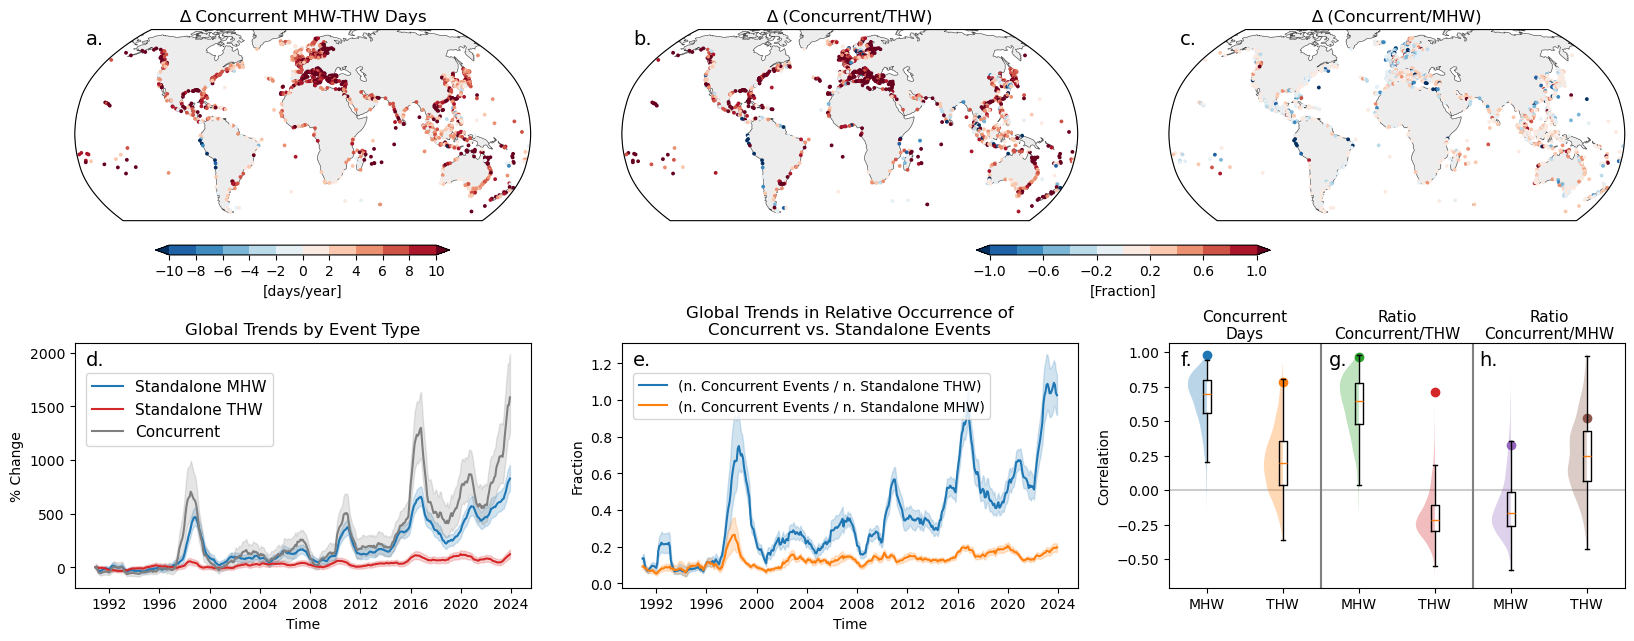

mhw
thw
con
PLOTTING.
Figure 2 Draft, Redone Eliminating Stations with T Inhomogeneities of >= 1˚C


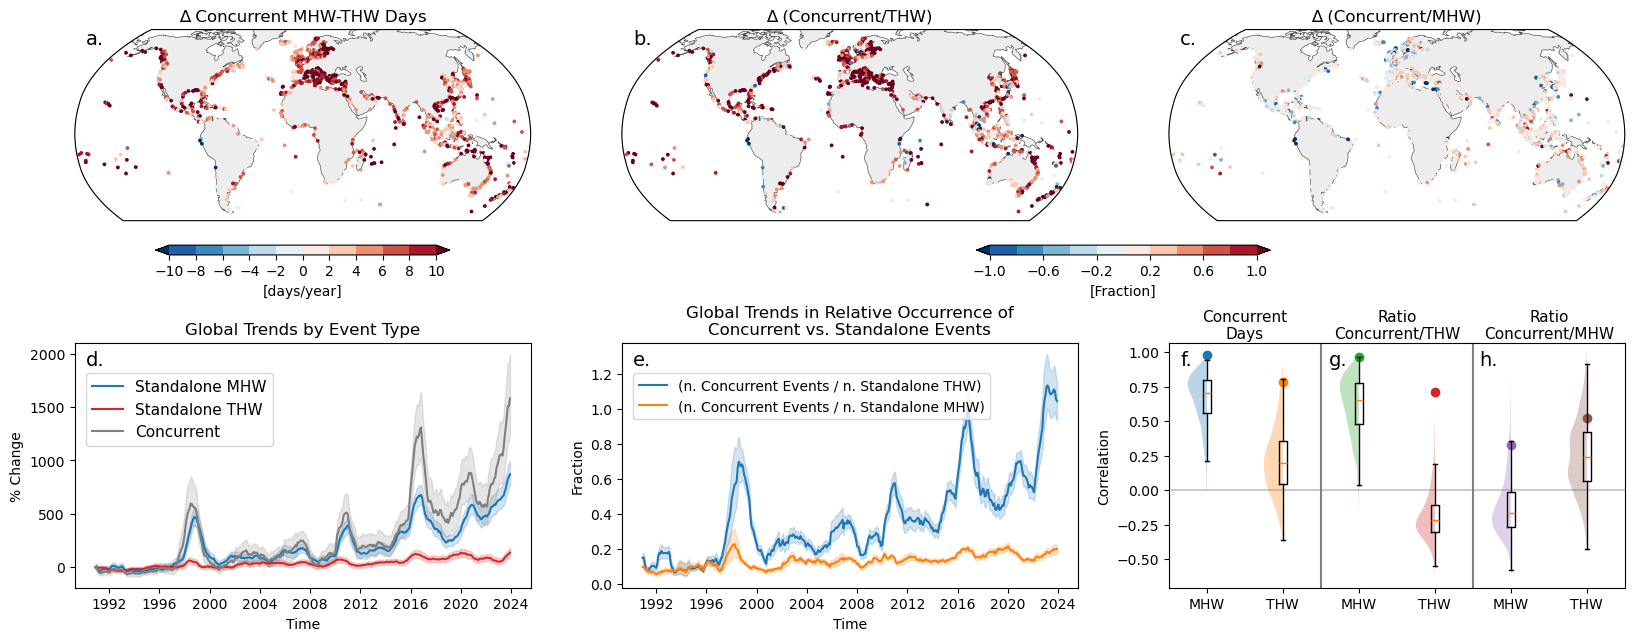

In [15]:
# loop across both T cutoffs to perform homogeneity test -- compute the data, etc. 

BIG_GDF = gdf

for LOOP in range(2):

    if LOOP==0:
        # select all locations that do NOT have inhomogeneities of <cutoff> ˚C for T 
        # (Note that I am NOT assessing stations with dewpoint inhomogeneities in this code because the THW events are identified using Tx data, nothing
        # to do with Td data). 
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_2_T'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_2_T']).to_numpy()
        cutoff = 2
    elif LOOP==1:
        gdf_T = BIG_GDF[np.logical_not(BIG_GDF['inhomog_1_T'])]
        Tmsk_arr = np.logical_not(BIG_GDF['inhomog_1_T']).to_numpy()
        cutoff = 1


        
    ### Compute regionally-stratified, bootstrap-resampled timeserieses in ∆ in no. MHW, THW, and concurrent days
    
    # first let's make monthly data
    mhw_so_mo = mhw_standalone_mask.resample(time='MS').sum()
    thw_so_mo = thw_standalone_mask.resample(time='MS').sum()
    con_mo = con_mhwthwdays.resample(time='MS').sum()
    
    timevals = con_mo.time.values
    
    # make a nested dict to make all this stuff easier
    event_trends_dict = {}
    
    invar_list = [mhw_so_mo[Tmsk_arr], thw_so_mo[Tmsk_arr], con_mo[Tmsk_arr]] # edited for homog. test
    
    # for each event type: 
    for evctr, ev_type in enumerate(['mhw', 'thw', 'con']):
    
        print(ev_type)
        event_trends_dict[ev_type] = {}
        in_da = invar_list[evctr]
    
        # compute the lat-binned, bootstrapped estimates of average event count timeserieses.
        ev_trends_binnedboots, bin_midpoints1, bin_n_obs1 = bin_lat_scatters_densitywtd_bootCI_forFig2d(latbins=np.arange(-60, 71, 3), lats=gdf_T.LAT.values, lons=gdf_T.LON.values, 
                                                                                                    dat=in_da, nboot=1000, radius_deg=3.0)
    
        # put into xarray DataArray
        evtrends_binnedboots_da = xr.DataArray(ev_trends_binnedboots, dims=['lat bin', 'boot', 'time'], 
                                               coords={'lat bin':bin_midpoints1, 'boot':np.array(range(1000)), 'time':timevals})
    
        # aggregate to global scale (weighting by bin area)
        evtrends_binnedboots_globalda = evtrends_binnedboots_da.weighted(np.cos(np.deg2rad(evtrends_binnedboots_da['lat bin']))).mean(dim='lat bin')
        event_trends_dict[ev_type]['evtrends_global_boots'] = evtrends_binnedboots_globalda # want to save this for fig. 2e
        
        # create % changes now that we're at global scale
        ev_ref90 = evtrends_binnedboots_globalda.sel(time=slice('1990-01-01', '1990-12-31')).mean(dim='time')
        evtrends_binnedboots_pctchange_globalda = ((evtrends_binnedboots_globalda - ev_ref90) / ev_ref90) * 100
    
        # generate bootstrapped global means and 95% ci
        event_trends_dict[ev_type]['pctchg_50'] = evtrends_binnedboots_pctchange_globalda.quantile(0.5, dim='boot')
        event_trends_dict[ev_type]['pctchg_50_r12'] = evtrends_binnedboots_pctchange_globalda.quantile(0.5, dim='boot').rolling(time=12).mean() # also save them as 12-month rolling means
        event_trends_dict[ev_type]['pctchg_975'] = evtrends_binnedboots_pctchange_globalda.quantile(0.975, dim='boot')
        event_trends_dict[ev_type]['pctchg_975_r12'] = evtrends_binnedboots_pctchange_globalda.quantile(0.975, dim='boot').rolling(time=12).mean()
        event_trends_dict[ev_type]['pctchg_025'] = evtrends_binnedboots_pctchange_globalda.quantile(0.025, dim='boot')
        event_trends_dict[ev_type]['pctchg_025_r12'] = evtrends_binnedboots_pctchange_globalda.quantile(0.025, dim='boot').rolling(time=12).mean()
    
    ## use the above to also compute ∆ in ratio of concurrent to standalone events ##
    
    # gen 1k bootstrap progressions of ratio <con/mhw> and <con/thw>
    ratio_con_mhw_mo_boots = (event_trends_dict['con']['evtrends_global_boots'] / event_trends_dict['mhw']['evtrends_global_boots'])
    ratio_con_thw_mo_boots = (event_trends_dict['con']['evtrends_global_boots'] / event_trends_dict['thw']['evtrends_global_boots'])
    
    # 12m rolling
    ratio_con_mhw_12moroll_boots = ratio_con_mhw_mo_boots.rolling(time=12).mean()
    ratio_con_thw_12moroll_boots = ratio_con_thw_mo_boots.rolling(time=12).mean()
    
    # get mean and CI
    ratio_con_mhw_12mo_50 = ratio_con_mhw_12moroll_boots.quantile(0.5, dim='boot')
    ratio_con_mhw_12mo_975 = ratio_con_mhw_12moroll_boots.quantile(0.975, dim='boot')
    ratio_con_mhw_12mo_025 = ratio_con_mhw_12moroll_boots.quantile(0.025, dim='boot')
    
    ratio_con_thw_12mo_50 = ratio_con_thw_12moroll_boots.quantile(0.5, dim='boot')
    ratio_con_thw_12mo_975 = ratio_con_thw_12moroll_boots.quantile(0.975, dim='boot')
    ratio_con_thw_12mo_025 = ratio_con_thw_12moroll_boots.quantile(0.025, dim='boot')



        
    ## PLOTTING, To SAVE figure for manuscript submission
    print('PLOTTING.')
    
    nrows = 2
    ncols = 3
    fig = plt.figure(figsize=(20, 7.5))
    gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
    gs.update(wspace=0.2, hspace=0.36)
    
    ax00 = fig.add_subplot(gs[0,0], projection=ccrs.Robinson())
    ax01 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())
    ax02 = fig.add_subplot(gs[0,2], projection=ccrs.Robinson())
    ax10 = fig.add_subplot(gs[1,0])
    ax11 = fig.add_subplot(gs[1,1])
    ax12 = fig.add_subplot(gs[1,2])
    
    # ax00 - ∆ n. concurrent days
    gdf_T.plot(delta_con_days[Tmsk_arr].data, markersize=3, ax=ax00, transform=ccrs.PlateCarree(), cmap=cmap_c, norm=norm_c)
    ax00.set(title='∆ Concurrent MHW-THW Days')
    
    # ax01 - ∆ ratio con/thw
    gdf_T.plot(delta_ratio_con_v_thw[Tmsk_arr].data, markersize=3, ax=ax01, transform=ccrs.PlateCarree(), cmap=cmap_r, norm=norm_r)
    ax01.set(title='∆ (Concurrent/THW)')
    
    # ax02 - ∆ ratio con/mhw
    gdf_T.plot(delta_ratio_con_v_mhw[Tmsk_arr].data, markersize=3, ax=ax02, transform=ccrs.PlateCarree(), cmap=cmap_r, norm=norm_r)
    ax02.set(title='∆ (Concurrent/MHW)')
    
    
    # add a colorbar(s)
    sm = plt.cm.ScalarMappable(norm=norm_c,cmap=cmap_c)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, ax=[ax00], orientation='horizontal', label="[days/year]", pad=0.1, use_gridspec=True, fraction=0.04, ticks=bounds_c,
                    extend='both', aspect=30)   
    
    
    sm = plt.cm.ScalarMappable(norm=norm_r,cmap=cmap_r)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, ax=[ax01, ax02], orientation='horizontal', label="[Fraction]", pad=0.1, use_gridspec=True, fraction=0.04, ticks=bounds_r[0::2],
                    extend='both', aspect=30)   
    
    # axis cosmetics
    for aa in [ax00, ax01, ax02]:
        aa.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
        aa.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0)
    
        
        
    # ax10 - change in event-types, in % (%∆ from 1990 value)?
    times_4plot = event_trends_dict['mhw']['pctchg_50_r12'].time.values
    
    event_trends_dict['mhw']['pctchg_50_r12'].plot(ax=ax10, color='tab:blue', label='Standalone MHW') # plot the standalone MHW's, and their CI
    ax10.fill_between(times_4plot, event_trends_dict['mhw']['pctchg_025_r12'], event_trends_dict['mhw']['pctchg_975_r12'], color='tab:blue', alpha=0.2)
    
    event_trends_dict['thw']['pctchg_50_r12'].plot(ax=ax10, color='tab:red', label='Standalone THW') # Plot THW
    ax10.fill_between(times_4plot, event_trends_dict['thw']['pctchg_025_r12'], event_trends_dict['thw']['pctchg_975_r12'], color='tab:red', alpha=0.2)
    
    event_trends_dict['con']['pctchg_50_r12'].plot(ax=ax10, color='tab:grey', label='Concurrent') # plot concurrent
    ax10.fill_between(times_4plot, event_trends_dict['con']['pctchg_025_r12'], event_trends_dict['con']['pctchg_975_r12'], color='tab:grey', alpha=0.2)
    
    #mhw_standalone_mo_pct_r12.plot(ax=ax10, label='Standalone MHW', color='tab:blue', ls='-')
    #thw_standalone_mo_pct_r12.plot(ax=ax10, label='Standalone THW', color='tab:red', ls='-', alpha=0.7)
    #con_mo_pct_r12.plot(ax=ax10, label='Concurrent', color='tab:grey', ls='-')
    
    ax10.set(xlabel='Time', ylabel='% Change', title='Global Trends by Event Type')
    ax10.legend(fontsize=11, loc=(0.025, 0.58))
    
    # ax11 - ratio of concurrent to standalone
    ratio_con_thw_12mo_50.plot(ax=ax11, color='tab:blue', label='(n. Concurrent Events / n. Standalone THW)', ls='-')
    ax11.fill_between(times_4plot, ratio_con_thw_12mo_025, ratio_con_thw_12mo_975, color='tab:blue', alpha=0.2)
    
    ratio_con_mhw_12mo_50.plot(ax=ax11, color='tab:orange', label='(n. Concurrent Events / n. Standalone MHW)', ls='-')
    ax11.fill_between(times_4plot, ratio_con_mhw_12mo_025, ratio_con_mhw_12mo_975, color='tab:orange', alpha=0.2)
    
    #ratio_con_v_thw_mo_r12.plot(ax=ax11, label='(n. Concurrent Events / n. Standalone THW)', ls='-')
    #ratio_con_v_mhw_mo_r12.plot(ax=ax11, label='(n. Concurrent Events / n. Standalone MHW)', ls='-')
    ax11.set(title='Global Trends in Relative Occurrence of\nConcurrent vs. Standalone Events', xlabel='Time', ylabel='Fraction')
    ax11.legend(loc=(0.025, 0.69))
    
    
    # ax12 - showing how MHW is most closely correlated with other qty's of interest. 
    
    ax=ax12
    data_list = [rconmhw_bysta[(~np.isnan(rconmhw_bysta)) * Tmsk_arr], rconthw_bysta[(~np.isnan(rconthw_bysta)) * Tmsk_arr],
               r_RatioConvTHW_mhw_bysta[(~np.isnan(r_RatioConvTHW_mhw_bysta)) * Tmsk_arr], r_RatioConvTHW_thw_bysta[(~np.isnan(r_RatioConvTHW_thw_bysta)) * Tmsk_arr],
               r_RatioConvMHW_mhw_bysta[(~np.isnan(r_RatioConvMHW_mhw_bysta)) * Tmsk_arr], r_RatioConvMHW_thw_bysta[(~np.isnan(r_RatioConvMHW_thw_bysta)) * Tmsk_arr]]
    
    ax.boxplot(data_list, widths=0.1, showfliers=False)
    
    for j, dat in enumerate(data_list):
        
        vplot = ax.violinplot(dat, showmedians=False, showextrema=False, positions=[j+1])
    
        # Modify paths for half-violin
        for body in vplot['bodies']:
            m = np.mean(body.get_paths()[0].vertices[:, 0])
            # Clip right side
            body.get_paths()[0].vertices[:, 0] = np.clip(body.get_paths()[0].vertices[:, 0], -np.inf, m)
    
    # scatter on the global-scale correlations
    ax.scatter(1, rconmhw_global)
    ax.scatter(2, rconthw_global)
    #ax.scatter(3, rmhwthw_global)
    ax.scatter(3, r_RatioConvTHW_mhw_global)
    ax.scatter(4, r_RatioConvTHW_thw_global)
    ax.scatter(5, r_RatioConvMHW_mhw_global)
    ax.scatter(6, r_RatioConvMHW_thw_global)
    
    # cosmetics
    ax.axvline(2.5, color='grey')
    ax.axvline(4.5, color='grey')
    ax.axhline(color='grey', alpha=0.4, zorder=0)
    
    # tick labels, titles, etc.
    ax.set_xticks(ticks=ax.get_xticks(), labels=['MHW', 'THW', 'MHW', 'THW', 'MHW', 'THW'])
    ax.text(s='Concurrent\nDays', x=1.5, y=1.1, ha='center', fontsize=11)
    ax.text(s='Ratio\nConcurrent/THW', x=3.5, y=1.1, ha='center', fontsize=11)
    ax.text(s='Ratio\nConcurrent/MHW', x=5.5, y=1.1, ha='center', fontsize=11)
    ax.set(ylabel='Correlation')
    
    ## subplot labels
    letters = ['a', 'b', 'c', 'd', 'e', 'f']
    
    for i, ax in enumerate([ax00, ax01, ax02, ax10, ax11, ax12]):
        if i<3:
            ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.925, transform=ax.transAxes, ha='left', fontsize=14)
        else: 
            ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.91, transform=ax.transAxes, ha='left', fontsize=14)
    
    # manualy add more subplot labels
    ax12.text(s='g.', x=0.35, y=0.91, transform=ax12.transAxes, ha='left', fontsize=14)
    ax12.text(s='h.', x=0.68, y=0.91, transform=ax12.transAxes, ha='left', fontsize=14)
    
    # # time & script
    # now = datetime.now() # get datetime
    # fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
    # fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')
    
    # SAVE FIGURE
    print('Figure 2 Draft, Redone Eliminating Stations with T Inhomogeneities of >= {}˚C'.format(cutoff))
    plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/FigSX_coastalsst_grl_6_26_Fig2HomogTest_{}degCutoff.png'.format(cutoff), format='png', bbox_inches='tight')
    
    plt.show()